# 🏠 House Price Prediction – Model Evaluation & Hyperparameter Tuning

## AI & ML Internship Task 3

### Objective

- Detect and control overfitting
- Apply cross-validation
- Perform hyperparameter tuning
- Compare multiple regression models
- Select the best-performing optimized model
- Improve model generalization

In [1]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# Load the Dataset
# ============================================

df = pd.read_csv("housing.csv")

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset loaded successfully!

Dataset Shape:
(20640, 10)

First 5 Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# 🔧 Data Preprocessing

In this step, the dataset is cleaned and prepared for machine learning.

The `total_bedrooms` column contains missing values, which are replaced using the median value. The categorical `ocean_proximity` feature is then converted into numerical features using One-Hot Encoding.

In [3]:
# ============================================
# Data Preprocessing
# ============================================

# Handle missing values
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

# Convert categorical feature into numerical values
df = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

print("Preprocessing completed successfully!")

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nUpdated Dataset Shape:")
print(df.shape)

Preprocessing completed successfully!

Missing Values:
0

Updated Dataset Shape:
(20640, 13)


# 🎯 Feature and Target Separation

The target variable is `median_house_value`, which represents the house price we want to predict.

All remaining columns are used as input features for the machine learning models.

In [4]:
# ============================================
# Separate Features and Target
# ============================================

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

print("Features and target separated successfully!")

print("\nFeatures Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

Features and target separated successfully!

Features Shape:
(20640, 12)

Target Shape:
(20640,)


# ✂️ Train-Test Split

The dataset is divided into training and testing sets.

- **80%** of the data is used for training the models.
- **20%** is used for testing their performance on unseen data.

A fixed `random_state` is used so that the same split is obtained every time the notebook is run.

In [7]:
# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split completed successfully!")

print("\nTraining Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("\nTraining Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Train-Test Split completed successfully!

Training Features: (16512, 12)
Testing Features: (4128, 12)

Training Target: (16512,)
Testing Target: (4128,)


# 📏 Feature Scaling

Feature scaling brings the numerical features to a similar scale using `StandardScaler`.

This helps machine learning models such as Linear Regression and Ridge Regression perform more effectively when features have very different ranges.

In [8]:
# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling completed successfully!")

print("\nScaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Feature Scaling completed successfully!

Scaled Training Shape: (16512, 12)
Scaled Testing Shape: (4128, 12)


# 🤖 Baseline Model Training

Before hyperparameter tuning, baseline models are trained using their default or basic configurations.

The following models are used:

- Linear Regression
- Ridge Regression
- Decision Tree Regressor

These baseline results will later be compared with the tuned models to evaluate whether hyperparameter optimization improves performance.

In [9]:
# ============================================
# Baseline Model Training
# ============================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

baseline_results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    baseline_results.append([name, rmse, r2])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "RMSE", "R² Score"]
)

print("Baseline Model Performance:")
display(baseline_df)

Baseline Model Performance:


,Model,RMSE,R² Score
0,Linear Regression,70060.521845,0.625424
1,Ridge Regression,70057.416870,0.625457
2,Decision Tree,71510.900484,0.609755


# 🎯 Hyperparameter Tuning

Hyperparameter tuning is used to find better parameter values for the Decision Tree Regressor.

GridSearchCV tests multiple combinations of hyperparameters using cross-validation and selects the combination that gives the best performance.

In [10]:
# ============================================
# Hyperparameter Tuning - Decision Tree
# ============================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_dt = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Decision Tree Model:")
print(best_dt)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Best Decision Tree Model:
DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)


# 📊 Tuned Model Evaluation

The optimized Decision Tree Regressor is evaluated on the testing dataset using RMSE and R² Score.

These metrics help determine whether hyperparameter tuning improved the model's performance.

In [11]:
# ============================================
# Evaluate Tuned Decision Tree
# ============================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_tuned = best_dt.predict(X_test_scaled)

# Evaluation metrics
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Decision Tree Performance")
print("--------------------------------")
print(f"RMSE: {rmse_tuned:.2f}")
print(f"R² Score: {r2_tuned:.4f}")

Tuned Decision Tree Performance
--------------------------------
RMSE: 60324.49
R² Score: 0.7223


# 📈 Baseline vs Tuned Model Comparison

The performance of the baseline models is compared with the optimized Decision Tree model.

This comparison helps determine whether hyperparameter tuning improved the model's predictive performance.

In [12]:
# ============================================
# Baseline vs Tuned Model Comparison
# ============================================

comparison_results = baseline_df.copy()

comparison_results.loc[len(comparison_results)] = [
    "Tuned Decision Tree",
    rmse_tuned,
    r2_tuned
]

print("Model Performance Comparison:")
display(comparison_results)

Model Performance Comparison:


,Model,RMSE,R² Score
0,Linear Regression,70060.521845,0.625424
1,Ridge Regression,70057.416870,0.625457
2,Decision Tree,71510.900484,0.609755
3,Tuned Decision Tree,60324.487515,0.722297


# 🔄 Cross-Validation

Cross-validation is used to evaluate the model on multiple training and validation splits.

In this project, 5-fold cross-validation is used to measure the consistency of the Decision Tree model's performance across different subsets of the training data.

In [17]:
# ============================================
# 5-Fold Cross-Validation
# ============================================

cv_scores = cross_val_score(
    DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("5-Fold Cross-Validation R² Scores:")
print(cv_scores)

print("\nMean Cross-Validation R² Score:")
print(f"{cv_scores.mean():.4f}")

print("\nStandard Deviation:")
print(f"{cv_scores.std():.4f}")

5-Fold Cross-Validation R² Scores:
[0.63589042 0.61662572 0.6231364  0.64052465 0.62482654]

Mean Cross-Validation R² Score:
0.6282

Standard Deviation:
0.0087


# Final Model Selection

The tuned Decision Tree Regressor achieved the best performance among all evaluated models.

It obtained the lowest RMSE and the highest R² Score, indicating that hyperparameter tuning significantly improved the model's predictive performance.

Therefore, the Tuned Decision Tree is selected as the final model.

In [13]:
# ============================================
# Save Final Tuned Model
# ============================================

import joblib

joblib.dump(grid_search.best_estimator_, "tuned_decision_tree_model.pkl")

print("Final tuned Decision Tree model saved successfully!")

Final tuned Decision Tree model saved successfully!


# 📉 Actual vs Predicted Values

The Actual vs Predicted plot compares the real house prices with the prices predicted by the final tuned Decision Tree model.

Points closer to the diagonal reference line indicate more accurate predictions.

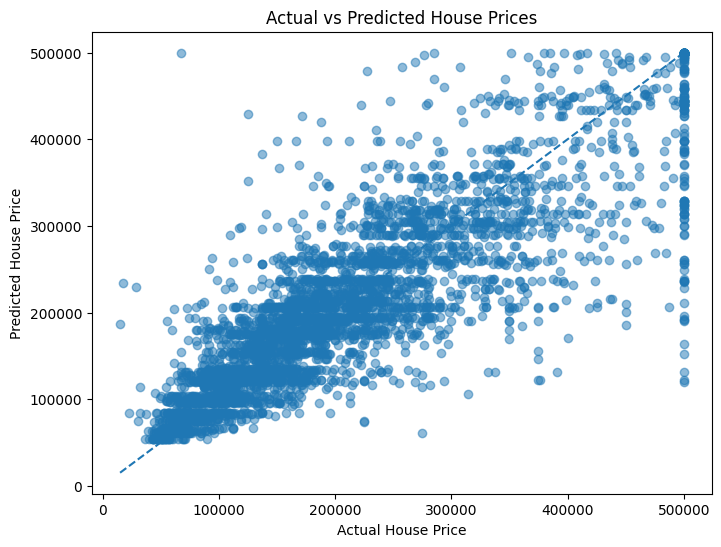

Actual vs Predicted plot saved successfully!


In [15]:
# ============================================
# Actual vs Predicted Plot
# ============================================

import os
import matplotlib.pyplot as plt

# Create images folder
os.makedirs("images", exist_ok=True)

# Predictions from final model
final_predictions = grid_search.best_estimator_.predict(X_test_scaled)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

# Save image
plt.savefig(
    "images/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Actual vs Predicted plot saved successfully!")

# 📊 Model Performance Comparison

The performance of all trained models is visualized using their R² Scores.

A higher R² Score indicates better predictive performance. The comparison clearly shows the improvement achieved after hyperparameter tuning.

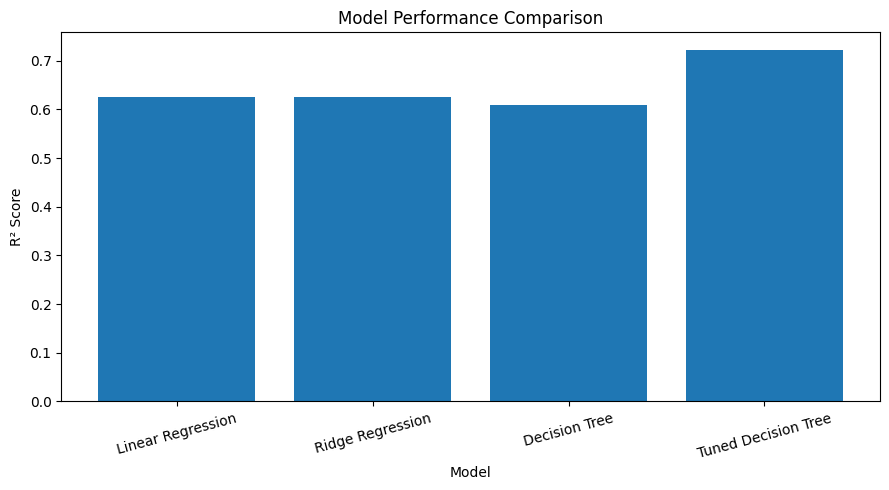

Model comparison plot saved successfully!


In [16]:
# ============================================
# Model Performance Comparison Plot
# ============================================

import os
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["R² Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.xticks(rotation=15)

plt.tight_layout()

# Save image
plt.savefig(
    "images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Model comparison plot saved successfully!")

# 📋 Final Summary

The house price prediction model was evaluated using multiple regression models and hyperparameter tuning.

The baseline Decision Tree was optimized using GridSearchCV with 5-fold cross-validation.

The tuned Decision Tree achieved the best performance with:

- RMSE: 60,324.49
- R² Score: 0.7223

The tuned Decision Tree is therefore selected as the final model.

In [18]:
# ============================================
# Final Results Summary
# ============================================

print("FINAL MODEL PERFORMANCE")
print("=" * 35)

print("Model: Tuned Decision Tree")
print(f"RMSE: {rmse_tuned:.2f}")
print(f"R² Score: {r2_tuned:.4f}")

print("\nBest Parameters:")
print(grid_search.best_params_)

FINAL MODEL PERFORMANCE
Model: Tuned Decision Tree
RMSE: 60324.49
R² Score: 0.7223

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
